# FIT5196 Assignment 2 - Task 2: Data Reshaping, Feature Engineering, and Advanced Analysis

**Group 032**

**Date:** October 2025

---


In [1]:
# 8.1 加载suburb_info.xlsx并初步查看
import pandas as pd
suburb_path = 'suburb_info.xlsx'
suburb_df = pd.read_excel(suburb_path)
print('数据维度:', suburb_df.shape)
print('字段:', list(suburb_df.columns))

# 修正百分号为数值（如68%→0.68）
for col in ['aus_born_perc']:
    if suburb_df[col].dtype == object:
        suburb_df[col] = suburb_df[col].str.rstrip('%').astype(float)
suburb_df['aus_born_perc'] = suburb_df['aus_born_perc'] / 100

# 修正带$和,的货币列为数值（如$1,797→1797.0）
for col in ['median_income', 'median_house_price']:
    if suburb_df[col].dtype == object:
        suburb_df[col] = suburb_df[col].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
suburb_df.head()

# Tips:
# - 读取Excel用read_excel，读取csv用read_csv。
# - 百分号和货币符号要先去掉再转为数值，否则后续分析会报错。

数据维度: (202, 8)
字段: ['suburb', 'number_of_houses', 'number_of_units', 'municipality', 'aus_born_perc', 'median_income', 'median_house_price', 'population']


,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,0.68,1797.0,1299400.0,4025
1,ABERFELDIE,1410,453,Moonee Valley,0.81,1571.0,1926600.0,22442
2,ALBANVALE,1897,138,Brimbank,0.46,907.0,594200.0,54005
3,ALBION,1389,1392,Brimbank,0.52,929.0,739100.0,30677
4,ALPHINGTON,1729,1099,Darebin,0.73,1538.0,1729600.0,9227


       aus_born_perc  number_of_units  number_of_houses    population  \
count     202.000000       202.000000        202.000000    202.000000   
mean        0.683663      2480.410891       4155.767327  18659.311881   
std         0.107613      3132.684712       3400.864988   9604.187282   
min         0.360000        60.000000        283.000000    170.000000   
25%         0.620000       620.500000       1973.500000  12063.000000   
50%         0.700000      1603.000000       3256.500000  17583.000000   
75%         0.770000      3089.000000       5518.500000  24045.000000   
max         0.880000     24380.000000      23338.000000  54005.000000   

       median_income  median_house_price  
count     202.000000        2.020000e+02  
mean     1387.935644        1.218817e+06  
std       317.841321        4.716807e+05  
min       633.000000        5.072000e+05  
25%      1182.250000        8.706750e+05  
50%      1393.000000        1.134500e+06  
75%      1560.000000        1.467550e+06 

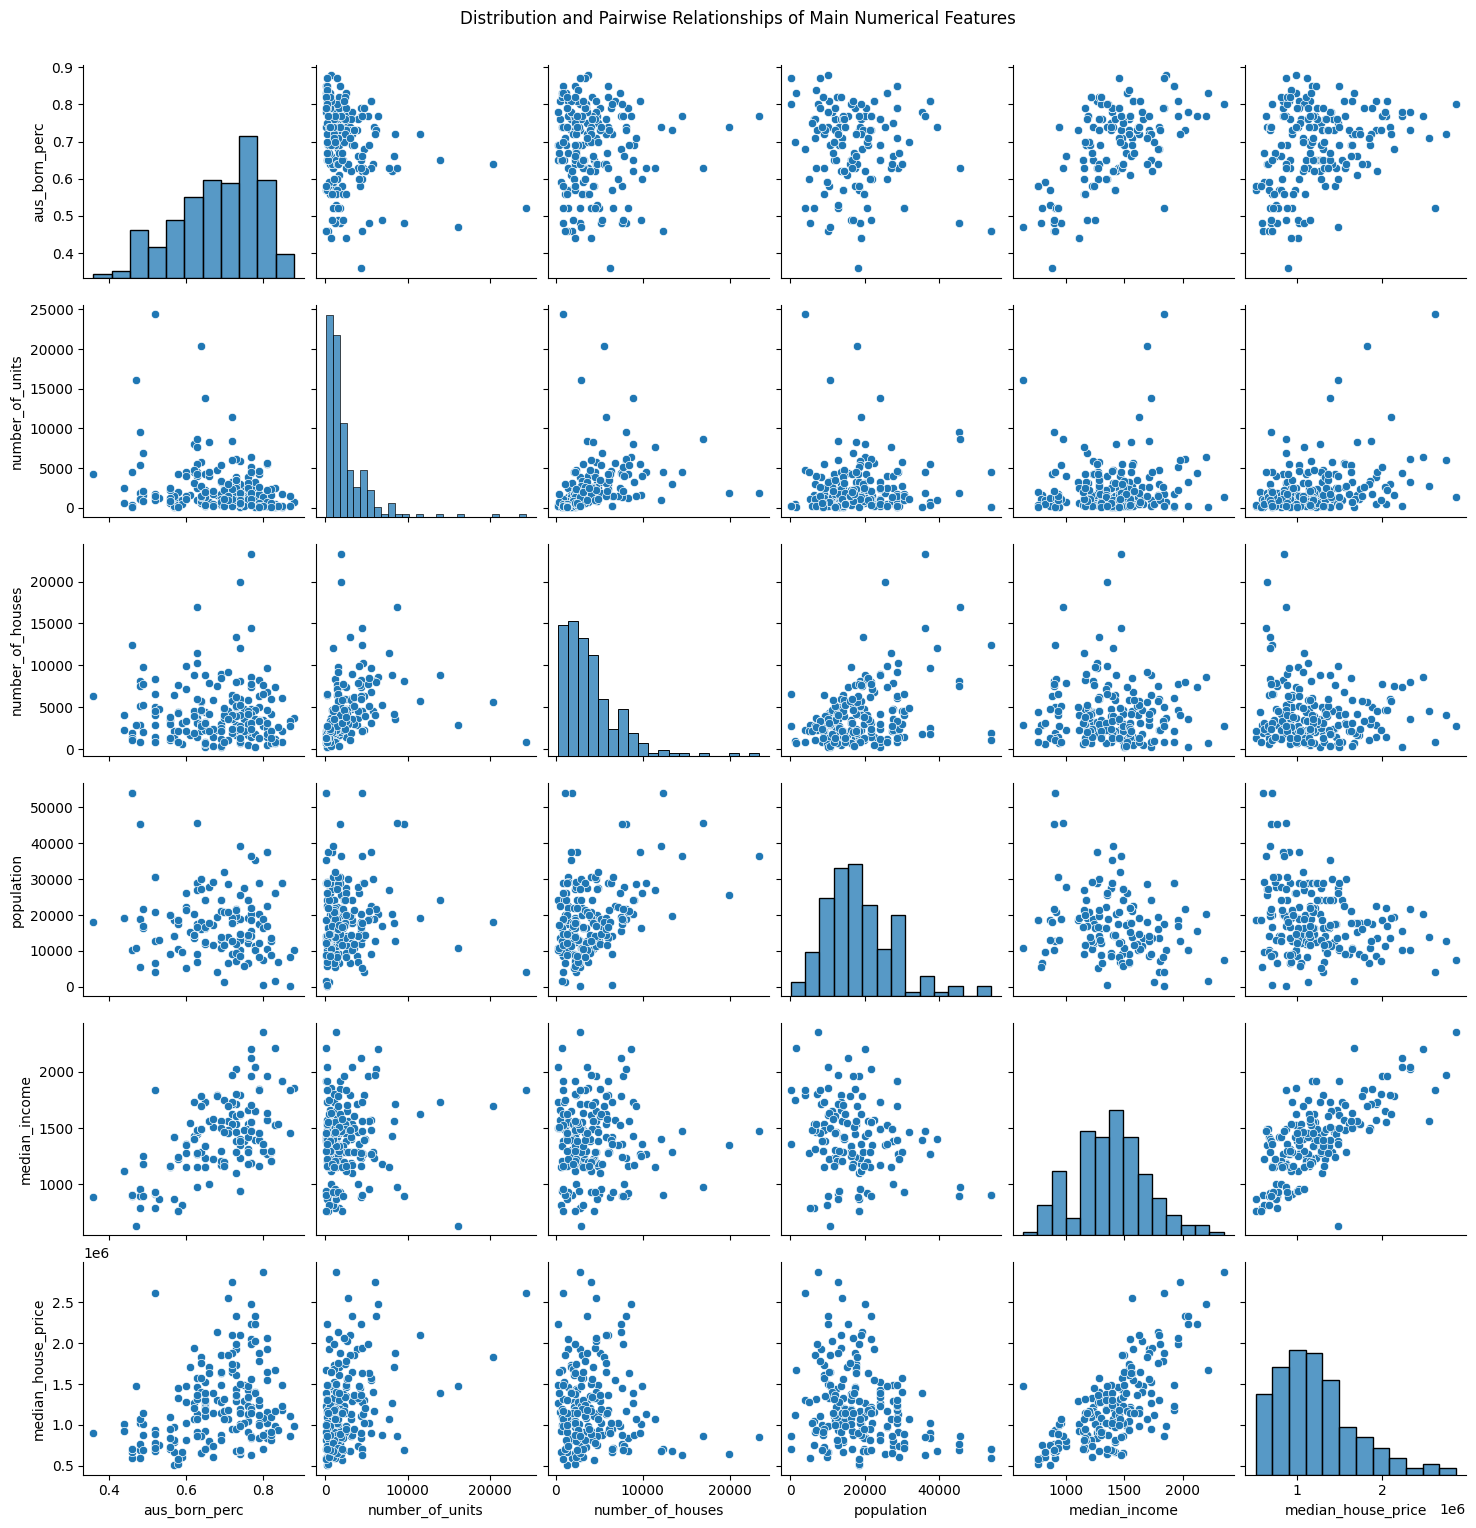

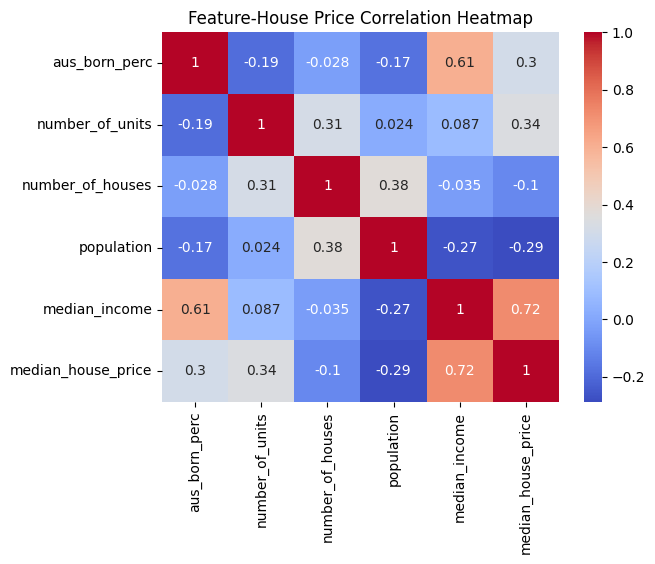

In [3]:
# 8.2 主要数值特征分布与相关性分析
num_cols = ['aus_born_perc', 'number_of_units', 'number_of_houses', 'population', 'median_income', 'median_house_price']
print(suburb_df[num_cols].describe())

import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(suburb_df[num_cols])
plt.suptitle('Distribution and Pairwise Relationships of Main Numerical Features', y=1.02)
plt.show()

corr = suburb_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature-House Price Correlation Heatmap')
plt.show()

# Tips:
# - describe() provides a quick overview of numerical feature distributions.
# - pairplot and heatmap help reveal feature correlations and outliers.

## 8.3 三种特征变换方法对比

- 标准化（Z-score）
- Min-Max归一化
- 对数变换（适用于偏态分布）

将对主要特征分别进行三种变换，并对比其与房价的相关性变化。

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# 1. 标准化（Z-score）
scaler_std = StandardScaler()
suburb_std = suburb_df[num_cols].copy()
suburb_std[num_cols[:-1]] = scaler_std.fit_transform(suburb_std[num_cols[:-1]])

# 2. Min-Max归一化
scaler_mm = MinMaxScaler()
suburb_mm = suburb_df[num_cols].copy()
suburb_mm[num_cols[:-1]] = scaler_mm.fit_transform(suburb_mm[num_cols[:-1]])

# 3. 对数变换（对偏态特征）
suburb_log = suburb_df[num_cols].copy()
for col in num_cols[:-1]:
    suburb_log[col] = np.log1p(suburb_log[col])

# 相关性对比
def show_corr(df, title):
    corr = df.corr()['median_house_price'].sort_values()
    print(f'{title} 与房价相关性:')
    print(corr)
    return corr

corr_std = show_corr(suburb_std, '标准化')
corr_mm = show_corr(suburb_mm, 'Min-Max归一化')
corr_log = show_corr(suburb_log, '对数变换')

# Tips:
# - 标准化和归一化能消除量纲影响，便于特征比较。
# - 对数变换适合处理偏态分布特征。

标准化 与房价相关性:
population           -0.287242
number_of_houses     -0.104490
aus_born_perc         0.303860
number_of_units       0.343858
median_income         0.719384
median_house_price    1.000000
Name: median_house_price, dtype: float64
Min-Max归一化 与房价相关性:
population           -0.287242
number_of_houses     -0.104490
aus_born_perc         0.303860
number_of_units       0.343858
median_income         0.719384
median_house_price    1.000000
Name: median_house_price, dtype: float64
对数变换 与房价相关性:
population           -0.156638
number_of_houses     -0.058902
aus_born_perc         0.309288
number_of_units       0.315883
median_income         0.682847
median_house_price    1.000000
Name: median_house_price, dtype: float64


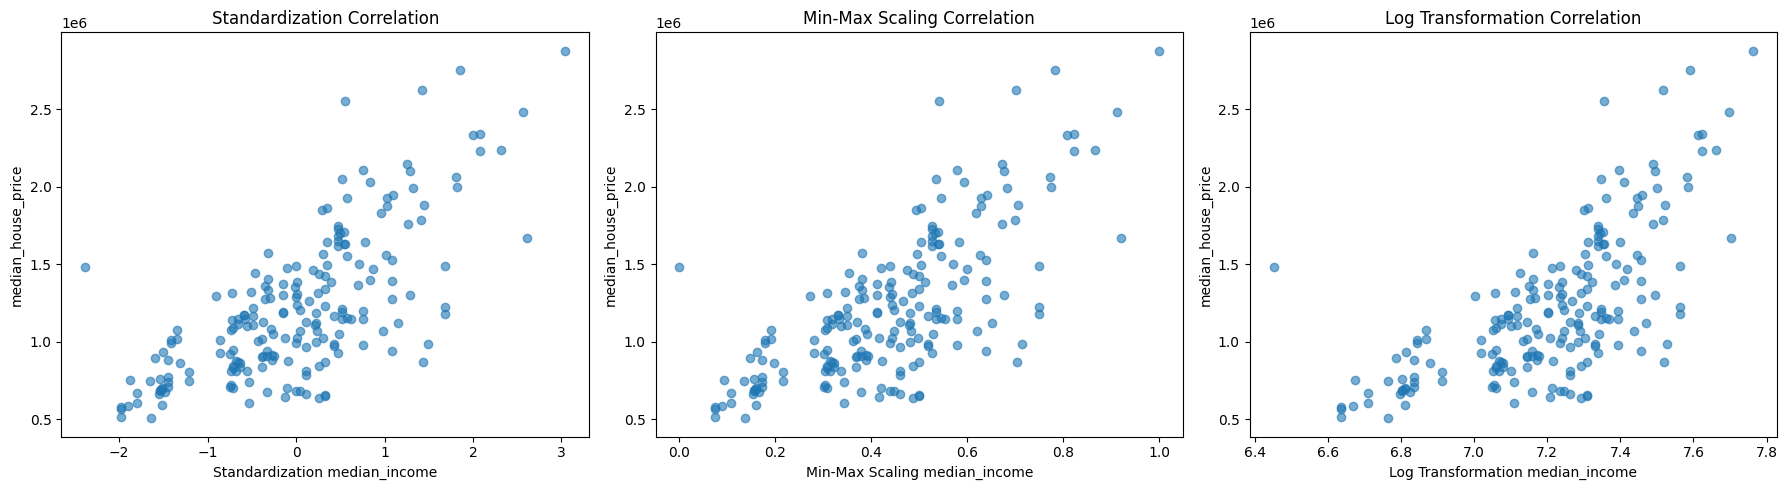

In [6]:
# 8.4 可视化三种变换后主要特征与房价的关系
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (df, name) in enumerate(zip([suburb_std, suburb_mm, suburb_log], ['Standardization', 'Min-Max Scaling', 'Log Transformation'])):
    axes[i].scatter(df['median_income'], df['median_house_price'], alpha=0.6)
    axes[i].set_xlabel(f'{name} median_income')
    axes[i].set_ylabel('median_house_price')
    axes[i].set_title(f'{name} Correlation')
plt.tight_layout()
plt.show()

# Tips:
# - 可视化有助于直观比较不同变换方法的效果。
# - D档建议每一步都配图和输出，便于理解和检查。